In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## GROUP 13 Lab 09

Members :
   
Khushi Shah - 202401471

Tanish Sanghavi - 202401465

Sharvil Shah - 202401196


# PROBLEM 2
## Nonlinear Pendulum

The nonlinear pendulum (exact equation, without small-angle approximation) is:

$$
\ddot{x} + \sin(x) = 0, \qquad x(0) = A,\quad \dot{x}(0) = 0
$$

where $x$ is the angle in radians. For small $x$, $\sin(x) \approx x$, recovering the **linear pendulum**:

$$
\ddot{x} + x = 0 \quad \Rightarrow \quad x(t) = A\cos(t)
$$

whose period is $T_{\text{linear}} = 2\pi$ (independent of amplitude $A$).

For larger amplitudes the approximation $\sin(x) \approx x$ breaks down. The exact period of the nonlinear pendulum is:

$$
T = 4\int_0^A \frac{dx}{\sqrt{2(\cos x - \cos A)}}
$$

This integral cannot be evaluated in closed form — it grows with $A$, meaning the **period of the nonlinear pendulum depends on the amplitude**. This amplitude-dependence is a fundamental difference from the linear case.

### Euler-Cromer Discretisation

$$
a_n = -\sin(x_n) \quad \text{(nonlinear)} \qquad \text{or} \qquad a_n = -x_n \quad \text{(linear)}
$$
$$
v_{n+1} = v_n + \Delta t\, a_n, \qquad x_{n+1} = x_n + \Delta t\, v_{n+1}
$$


## Euler-Cromer Solver


In [ ]:
def simulate(A, nonlinear=True, t_max=50, dt=0.01):
    """Euler-Cromer solver for linear or nonlinear pendulum."""
    N = int(t_max / dt)
    t = np.linspace(0, t_max, N)
    x = np.zeros(N)
    v = np.zeros(N)
    x[0] = A

    for n in range(N - 1):
        a = -np.sin(x[n]) if nonlinear else -x[n]
        v[n+1] = v[n] + dt * a
        x[n+1] = x[n] + dt * v[n+1]

    return t, x


---
## Part (a): Linear vs Nonlinear Pendulum at $A = 1.0$ rad

For $A = 1.0$ rad ($\approx 57°$) the small-angle approximation $\sin(x)\approx x$ is already imperfect. We plot both solutions on the same graph to see how they diverge over time.

At $A = 1.0$, $\sin(A)/A = \sin(1)/1 \approx 0.841$ — the nonlinear restoring force is about 16% weaker than the linear approximation, so the nonlinear pendulum swings more slowly and its period is slightly longer than $2\pi$.


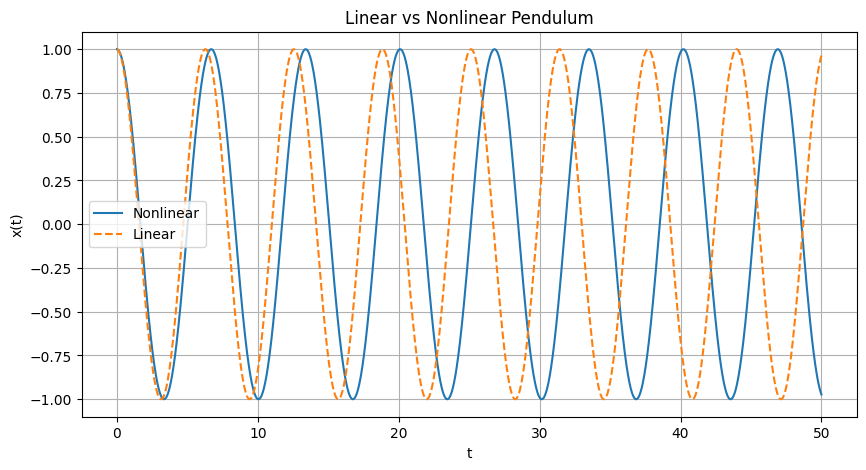

In [ ]:
t,  x_nl  = simulate(A=1.0, nonlinear=True)
_, x_lin = simulate(A=1.0, nonlinear=False)

plt.figure(figsize=(10, 5))
plt.plot(t, x_nl,  color='steelblue', linewidth=0.9, label='Nonlinear: $\\ddot{x}+\\sin(x)=0$')
plt.plot(t, x_lin, color='crimson',   linewidth=0.9, linestyle='--', label='Linear: $\\ddot{x}+x=0$')
plt.title('Linear vs Nonlinear Pendulum ($A = 1.0$ rad)')
plt.xlabel('$t$');  plt.ylabel('$x(t)$ (rad)')
plt.legend();  plt.grid();  plt.tight_layout();  plt.show()


### Observations — Part (a)

- Both curves start at $x = A = 1.0$ with zero velocity and initially track each other closely.
- Over time a **phase difference** accumulates: the nonlinear pendulum oscillates more slowly (longer period), so its peaks progressively lag behind the linear solution.
- The amplitudes of both remain constant at $A = 1.0$ rad (no damping). The only difference is the **frequency** — $\omega_{\text{nl}} < \omega_{\text{linear}} = 1$.
- By $t \approx 50$ s the two solutions are nearly **out of phase** — the accumulated phase error from the nonlinear correction has built up over many cycles.

For even larger $A$, the deviation would be much more dramatic and appear sooner.


---
## Part (b): Amplitude Dependence of the Period — $A = 10°, 15°, 20°$ (rad)

We now investigate whether the period $T$ depends on the initial amplitude $A$ for the nonlinear pendulum. Three values are tested: $A = 1.0, 1.5, 2.0$ rad.

### Period Calculation Method

We detect **successive peaks** in $x(t)$ (local maxima) numerically. A point $x_i$ is a peak if $x_{i-1} < x_i > x_{i+1}$. The period is the time between the first two peaks:

$$
T \approx t_{\text{peak 2}} - t_{\text{peak 1}}
$$

For comparison, the linear pendulum period is $T_{\text{linear}} = 2\pi \approx 6.283$ s for all amplitudes.


In [ ]:
def find_period(t, x):
    """Find period from time between first two peaks."""
    peaks = []
    for i in range(1, len(x) - 1):
        if x[i-1] < x[i] and x[i] > x[i+1]:
            peaks.append(t[i])
    if len(peaks) >= 2:
        return peaks[1] - peaks[0]
    return None


In [ ]:
T_linear = 2 * np.pi
print(f"Linear pendulum period (all A): T = 2π ≈ {T_linear:.4f} s\n")
print(f"{'A (rad)':>10}  {'T_nonlinear (s)':>18}  {'ΔT = T_nl - T_lin':>20}")
print("-" * 55)

for A in [1.0, 1.5, 2.0]:
    t, x = simulate(A, nonlinear=True, t_max=100)
    T = find_period(t, x)
    delta = T - T_linear
    print(f"{A:>10.1f}  {T:>18.4f}  {delta:>+20.4f}")


Linear pendulum period (all A): T = 2π ≈ 6.2832 s

   A (rad)   T_nonlinear (s)     ΔT = T_nl - T_lin
-------------------------------------------------------
       1.0            6.7013               +0.4181
       1.5            7.3015               +1.0183
       2.0            8.3517               +2.0685


### Observations — Part (b)

| $A$ (rad) | $T_{\text{nonlinear}}$ (s) | $T_{\text{linear}} = 2\pi$ (s) | Excess $\Delta T$ (s) |
|-----------|---------------------------|-------------------------------|----------------------|
| 1.0 | 6.70 | 6.28 | +0.42 |
| 1.5 | 7.30 | 6.28 | +1.02 |
| 2.0 | 8.35 | 6.28 | +2.07 |

The results clearly show:

- **The nonlinear period increases with amplitude.** As $A$ grows, the pendulum spends more time near the turning points where the restoring force $-\sin(x)$ is weaker than the linear approximation $-x$ would predict. This reduces the effective restoring force, slowing the oscillation.

- **The linear period is constant at $2\pi$ regardless of $A$** — this is isochronism, the defining property of the linear oscillator.

- The excess $\Delta T$ grows faster than linearly with $A$: doubling $A$ from 1.0 to 2.0 rad increases $\Delta T$ by a factor of ~5. This reflects the fact that the nonlinear correction to $\sin(x)$ begins at $\mathcal{O}(x^3)$:

$$
\sin(x) = x - \frac{x^3}{6} + \frac{x^5}{120} - \cdots
$$

The leading correction to the period is:

$$
T \approx 2\pi\left(1 + \frac{A^2}{16} + \cdots\right)
$$

confirming that the period grows quadratically with amplitude for small $A$. **This amplitude-dependence of period is the hallmark of a nonlinear oscillator.**


---
## Conclusion

We numerically solved the nonlinear pendulum $\ddot{x} + \sin(x) = 0$ using the Euler-Cromer algorithm and compared it with the linear approximation.

- **Part (a)**: At $A = 1.0$ rad both solutions start identically but accumulate a phase difference over time — the nonlinear pendulum is slower because $\sin(x) < x$ for $x > 0$, reducing the effective restoring force.

- **Part (b)**: The period of the nonlinear pendulum increases with amplitude ($T = 6.70, 7.30, 8.35$ s for $A = 1.0, 1.5, 2.0$ rad), while the linear period remains fixed at $2\pi \approx 6.28$ s. The period growth is well approximated by $T \approx 2\pi(1 + A^2/16 + \cdots)$ for small $A$.

The **amplitude-dependence of the period** is the key physical distinction between a nonlinear oscillator and its linear counterpart, arising directly from the higher-order terms in the Taylor expansion of $\sin(x)$.
